In [71]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

hours = np.random.normal(5, 2, n).clip(0, 12)
attendance = np.random.normal(80, 15, n).clip(30, 100)
assignments = np.random.randint(0, 11, n)
gpa = np.random.normal(7.0, 1.2, n).clip(3, 10)
sleep = np.random.normal(6.8, 1.3, n).clip(3, 10)

score = (
    hours * 0.25 +
    attendance * 0.03 +
    assignments * 0.35 +
    gpa * 0.8 +
    sleep * 0.1 +
    np.random.normal(0, 1.2, n)
)

passed = (score > 11).astype(int)

df = pd.DataFrame({
    "Hours_Studied": hours.round(2),
    "Attendance": attendance.round(2),
    "Assignments_Completed": assignments,
    "Previous_GPA": gpa.round(2),
    "Sleep_Hours": sleep.round(2),
    "Passed": passed
})
df.to_csv("student_admission.csv", index=False)

print(df.head())

   Hours_Studied  Attendance  Assignments_Completed  Previous_GPA  \
0           5.99       85.37                      2          8.43   
1           4.72       88.41                      0          6.95   
2           6.30       96.25                      4          7.21   
3           8.05       95.81                      6          8.09   
4           4.53       59.33                      5          6.99   

   Sleep_Hours  Passed  
0         6.34       1  
1         7.13       1  
2         7.17       1  
3         6.85       1  
4         5.07       0  


In [72]:
df

,Hours_Studied,Attendance,Assignments_Completed,Previous_GPA,Sleep_Hours,Passed
0,5.99,85.37,2,8.43,6.34,1
1,4.72,88.41,0,6.95,7.13,1
2,6.30,96.25,4,7.21,7.17,1
3,8.05,95.81,6,8.09,6.85,1
4,4.53,59.33,5,6.99,5.07,0
...,...,...,...,...,...,...
195,5.77,72.96,5,8.31,7.44,1
196,3.23,54.30,4,8.42,7.44,1
197,5.31,100.00,5,6.20,6.02,1
198,5.12,78.28,5,8.14,6.50,1


In [73]:
df.describe()

,Hours_Studied,Attendance,Assignments_Completed,Previous_GPA,Sleep_Hours,Passed
count,200.000000,200.0000,200.000000,200.000000,200.000000,200.000000
mean,4.919600,80.4668,4.830000,7.106950,6.918950,0.695000
std,1.858707,13.1855,3.176721,1.254792,1.384493,0.461563
min,0.000000,31.3800,0.000000,3.660000,3.180000,0.000000
25%,3.592500,70.9150,2.000000,6.270000,5.940000,0.000000
50%,4.990000,81.1850,5.000000,7.185000,6.800000,1.000000
75%,6.000000,90.3050,8.000000,7.980000,7.782500,1.000000
max,10.440000,100.0000,10.000000,10.000000,10.000000,1.000000


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Hours_Studied          200 non-null    float64
 1   Attendance             200 non-null    float64
 2   Assignments_Completed  200 non-null    int32  
 3   Previous_GPA           200 non-null    float64
 4   Sleep_Hours            200 non-null    float64
 5   Passed                 200 non-null    int64  
dtypes: float64(4), int32(1), int64(1)
memory usage: 8.7 KB


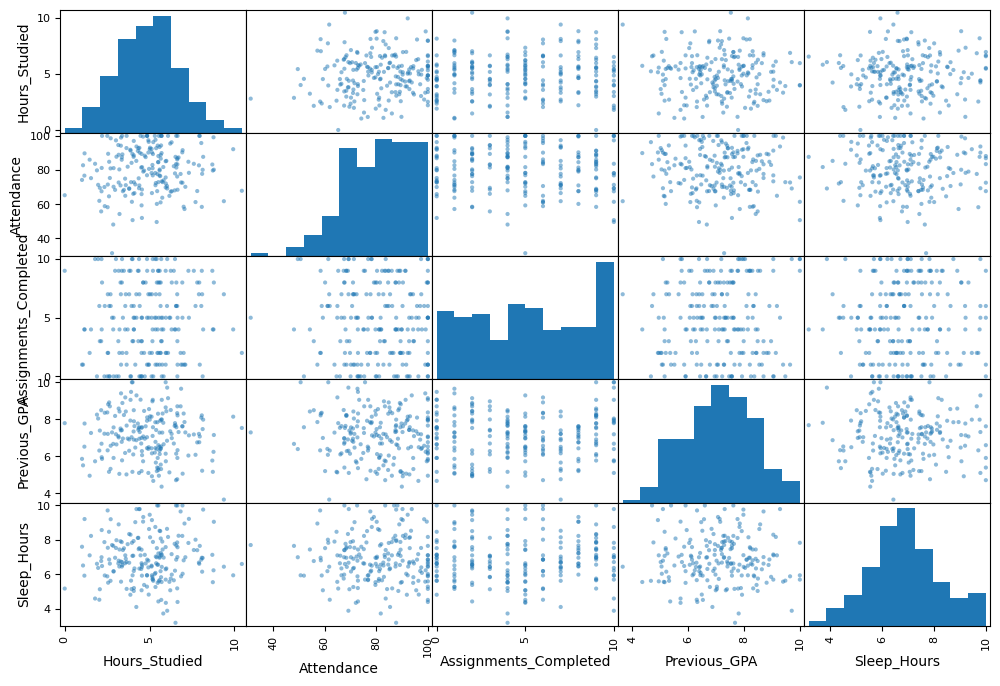

In [75]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
attributes = ["Hours_Studied", "Attendance", "Assignments_Completed", "Previous_GPA", "Sleep_Hours"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

In [76]:
x = df.iloc[:, :5]
y = df.iloc[:, -1]

In [77]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

In [78]:
x_test

,Hours_Studied,Attendance,Assignments_Completed,Previous_GPA,Sleep_Hours
54,7.06,57.21,1,7.85,8.95
111,4.95,96.48,5,6.49,4.82
19,2.18,81.23,4,5.95,8.57
31,8.70,83.25,9,5.77,7.13
136,3.43,67.62,5,6.96,7.41
134,3.16,94.63,3,7.09,6.63
39,5.39,92.79,5,7.42,6.64
182,2.86,48.14,4,6.67,7.65
165,5.83,73.98,0,6.65,6.97
80,4.56,81.70,5,6.06,6.55


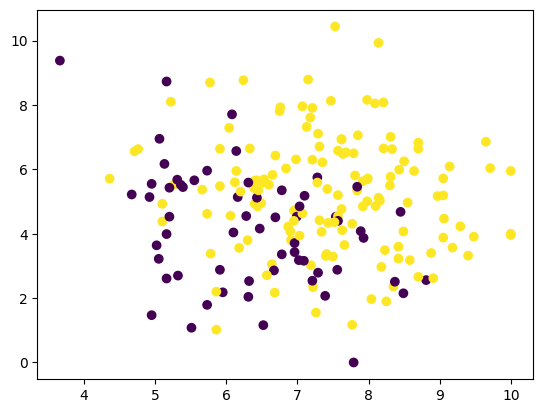

In [88]:
plt.scatter(df['Previous_GPA'], df['Hours_Studied'], c=df['Passed'])

In [80]:
scaler.fit(x_train)

x_train = scaler.transform(x_train)

x_test = scaler.transform(x_test)

In [81]:
from sklearn.linear_model import LogisticRegression

In [82]:
clf = LogisticRegression()

In [83]:
clf.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [84]:
y_pred = clf.predict(x_test)

In [85]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8